# Explore here

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import sqlite3
from sqlalchemy import create_engine


# 1) Explore API

In [16]:
url = "https://api.worldbank.org/v2/country"

params = {
    "format": "json",
    "per_page": 5,
    "page": 1
}

response = requests.get(url, params=params)

print(response.status_code)

200


# 2) Download data

In [17]:
countries = ["MEX", "USA", "CAN", "JPN", "BRA"]

indicators = {
    "population": "SP.POP.TOTL",
    "gdp_per_capita": "NY.GDP.PCAP.CD",
    "life_expectancy": "SP.DYN.LE00.IN"
}

all_data = []

In [18]:
BASE_URL = "https://api.worldbank.org/v2"

for country in countries:
    for indicator_name, indicator_code in indicators.items():
        url = f"{BASE_URL}/country/{country}/indicator/{indicator_code}"

        params = {
            "format": "json",
            "date": "2010:2024",
            "per_page": 100
        }

        response = requests.get(url, params=params)
        data = response.json()

        print(country, indicator_name, response.status_code)

MEX population 200
MEX gdp_per_capita 200
MEX life_expectancy 200
USA population 200
USA gdp_per_capita 200
USA life_expectancy 200
CAN population 200
CAN gdp_per_capita 200
CAN life_expectancy 200
JPN population 200
JPN gdp_per_capita 200
JPN life_expectancy 200
BRA population 200
BRA gdp_per_capita 200
BRA life_expectancy 200


In [19]:
all_data = []

for country in countries:
    for indicator_name, indicator_code in indicators.items():

        url = f"{BASE_URL}/country/{country}/indicator/{indicator_code}"

        params = {
            "format": "json",
            "date": "2010:2024",
            "per_page": 100
        }

        response = requests.get(url, params=params)
        data = response.json()

        if len(data) > 1:

            for item in data[1]:

                row = {
                    "country": country,
                    "indicator": indicator_name,
                    "year": item["date"],
                    "value": item["value"]
                }

                all_data.append(row)

print("Total rows:", len(all_data))

Total rows: 225


# 3) Create DataFrame

In [20]:
df = pd.DataFrame(all_data)

df.head()

,country,indicator,year,value
0,MEX,population,2024,130861007.0
1,MEX,population,2023,129739759.0
2,MEX,population,2022,128613117.0
3,MEX,population,2021,127648148.0
4,MEX,population,2020,126799054.0


In [21]:
df = df.dropna()

df["year"] = df["year"].astype(int)

df["value"] = pd.to_numeric(df["value"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    225 non-null    str    
 1   indicator  225 non-null    str    
 2   year       225 non-null    int64  
 3   value      225 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 7.2 KB


# 4) Analysis and visualizations

In [ ]:
## 4.1 Population growth by country

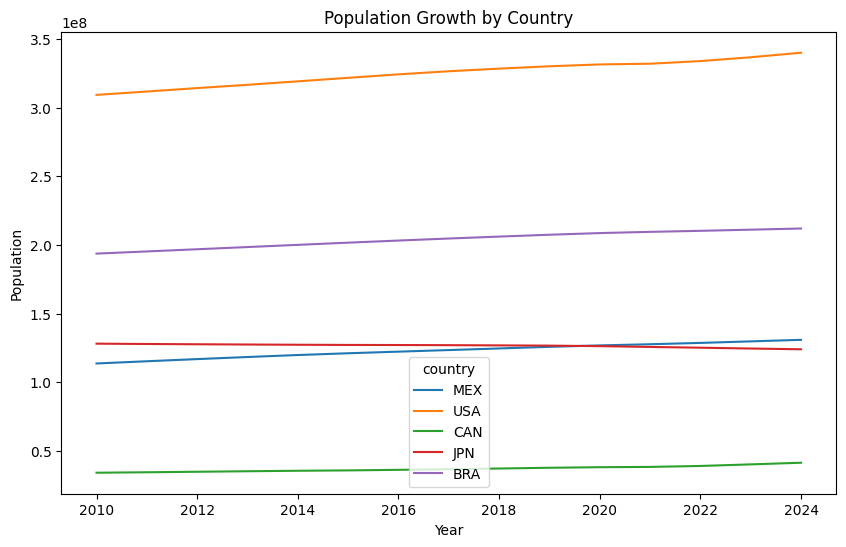

In [22]:
population_df = df[df["indicator"] == "population"]

plt.figure(figsize=(10,6))

sns.lineplot(
    data=population_df,
    x="year",
    y="value",
    hue="country"
)

plt.title("Population Growth by Country")
plt.xlabel("Year")
plt.ylabel("Population")

plt.show()

## 4.2 Relationship between population and GDP per capita

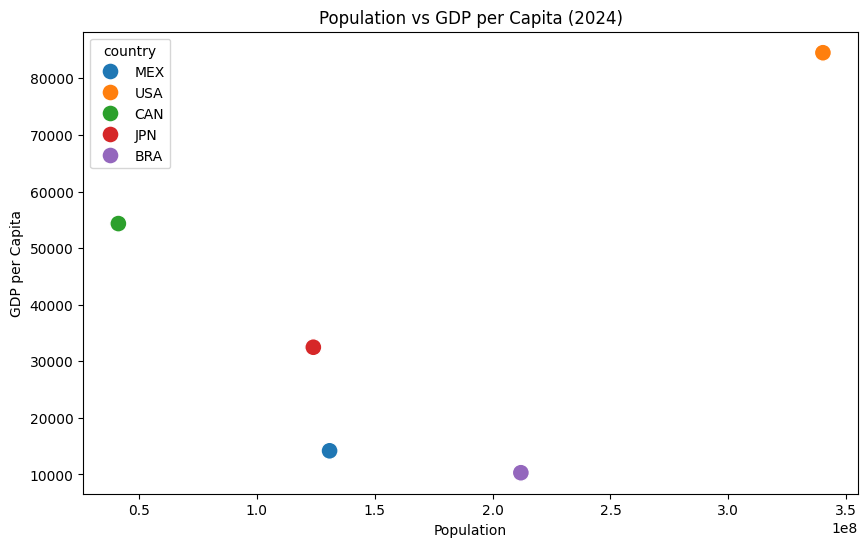

In [23]:
population_2024 = df[
    (df["indicator"] == "population") &
    (df["year"] == 2024)
]

gdp_2024 = df[
    (df["indicator"] == "gdp_per_capita") &
    (df["year"] == 2024)
]

merged_df = pd.merge(
    population_2024,
    gdp_2024,
    on="country"
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x="value_x",
    y="value_y",
    hue="country",
    s=150
)

plt.xlabel("Population")
plt.ylabel("GDP per Capita")
plt.title("Population vs GDP per Capita (2024)")

plt.show()

# 5) Load results to SQL database

In [24]:
conn = sqlite3.connect("world_bank_analysis.db")

df.to_sql(
    "world_bank_data",
    conn,
    if_exists="replace",
    index=False
)

print("Data saved successfully")

query = "SELECT * FROM world_bank_data LIMIT 5"

result = pd.read_sql(query, conn)

print(result)

conn.close()

Data saved successfully
  country   indicator  year        value
0     MEX  population  2024  130861007.0
1     MEX  population  2023  129739759.0
2     MEX  population  2022  128613117.0
3     MEX  population  2021  127648148.0
4     MEX  population  2020  126799054.0
